# pandas를 사용한 데이터 분석 
 
### 파일 읽기
 
대부분의 데이터셋은 열과 열을 구분하기 위한 구분자로 특정한 문자를 사용한다. 구분자는 보통 콤마 ','를 많이 쓰는데, 콤마를 구분자로 사용한 파일을 특별히 'CSV(comma-separated values) 파일'이라고 부른다.
  
 ** df = pd.read_csv("data/lending-club-loan-data/loan.csv", sep=",")** 

 
### Lending Club Loan dataset 분석하기
 
** Lending Club Loan dataset의 주요 컬럼 요약** 
 
 • loan_amnt: 대출자의 대출 총액
 
 • funded_amnt: 해당 대출을 위해 모금된 총액
 
 • issue_d: 대출을 위한 기금이 모금된 월
 
 • loan_status: 대출의 현재 상태*
 
 • title: 대출자에 의해 제공된 대출 항목
 
 • purpose: 대출자에 의해 제공된 대출 목적
 
 • emp_length: 대출자의 재직 기간
 
 • grade: LC assigned loan grade**
 
 • int_rate: 대출 이자율
 
 • term: 대출 상품의 기간 (36-month vs. 60-month)
  
* 불량 상태(bad status): "Charged Off", "Default", "Does not meet the credit policy. Status:Charged Off", "In Grace Period", "Default Receiver", "Late (16-30 days)", "Late (31-120 days)"
 
** LC loan grade 참고: https://www.lendingclub.com/public/rates-and-fees.action  **

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/loan.csv', sep = ',')

C:\Users\human\AppData\Local\Temp\ipykernel_11592\2519303798.py:1: DtypeWarning: Columns (19,47,55,112,123,124,125,128,129,130,133,139,140,141) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/loan.csv', sep = ',')


In [3]:
df.head(10)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,5550,5550,5550.0,36 months,15.02,192.45,C,C3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,2000,2000,2000.0,36 months,17.97,72.28,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,6000,6000,6000.0,36 months,13.56,203.79,C,C1,...,NaN,NaN,DirectPay,N,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,6000,6000,6000.0,36 months,14.47,206.44,C,C2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.shape

(2260668, 145)

In [5]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=145)

In [6]:
# 필요한 컬럼만 가져오기
df2 = df[['loan_amnt', 'loan_status', 'grade', 'int_rate', 'term']]

In [7]:
df2.head(10)

,loan_amnt,loan_status,grade,int_rate,term
0,2500,Current,C,13.56,36 months
1,30000,Current,D,18.94,60 months
2,5000,Current,D,17.97,36 months
3,4000,Current,D,18.94,36 months
4,30000,Current,C,16.14,60 months
5,5550,Current,C,15.02,36 months
6,2000,Current,D,17.97,36 months
7,6000,Current,C,13.56,36 months
8,5000,Current,D,17.97,36 months
9,6000,Current,C,14.47,36 months


In [8]:
df2.tail()

,loan_amnt,loan_status,grade,int_rate,term
2260663,12000,Current,C,14.08,60 months
2260664,12000,Fully Paid,E,25.82,60 months
2260665,10000,Current,B,11.99,36 months
2260666,12000,Current,D,21.45,60 months
2260667,16550,Current,D,21.45,60 months


In [9]:
df2['loan_status'].unique()

array(['Current', 'Fully Paid', 'Late (31-120 days)', 'In Grace Period',
       'Charged Off', 'Late (16-30 days)', 'Default',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

In [10]:
df2['grade'].unique()

array(['C', 'D', 'B', 'A', 'E', 'F', 'G'], dtype=object)

In [11]:
df2['term'].unique()

array([' 36 months', ' 60 months'], dtype=object)

In [12]:
df2.shape

(2260668, 5)

In [13]:
#nan 제거하기   * how = 'any' 는 nan이 있는 행은 모두 삭제 / how ='all' 은 행 전체에 nan이 있는 경우에만 행 삭제. 그렇지 않으면 삭제 안함
df2 = df2.dropna(how = 'any')

In [14]:
df2.shape

(2260668, 5)

# 30개월 / 60개월 두 가지 대출 상품을 운영
# 문제) '36개월 대출'과 '60개월 대출'의 대출 총액 파악

In [8]:
# 결과를 저장할 딕셔너리 생성
term_to_loan_amnt_dict = {}
# term 컬럼의 고유값 추출
uniq_terms = df2['term'].unique()

In [9]:
# 각 대출기간(term)에 대해 반복
# 해당 행들의 loan_amnt(대출금액) 컬럼 합계 계산
for term in uniq_terms:
    loan_amnt_sum = df2.loc[df2['term'] == term, 'loan_amnt'].sum() 
    #--> #df2.loc[df2['term'] 값이 uniq_term의 term과 같으면, 'loan_amnt'의 열을 갖고와서 sum을 해라
    
    # 계산된 합계를 딕셔너리에 저장
    term_to_loan_amnt_dict[term] = loan_amnt_sum

In [10]:
term_to_loan_amnt_dict

{' 36 months': 20517162875, ' 60 months': 13498953050}

In [29]:
#Series로 나타내기
# term_to_loan_amnt = pd.Series(term_to_loan_amnt_dict)
# term_to_loan_amnt

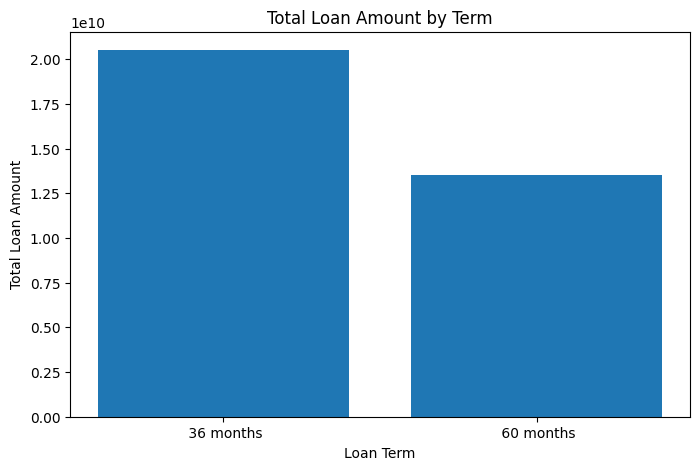

In [13]:
plt.figure(figsize=(8,5))

plt.bar(
    term_to_loan_amnt_dict.keys(),
    term_to_loan_amnt_dict.values()
)

plt.title('Total Loan Amount by Term')
plt.xlabel('Loan Term')
plt.ylabel('Total Loan Amount')

plt.show()
plt.close()

# 문제) 각 대출 상태(불량/우량)에 따른 대출 등급 분포 파악

In [15]:
df2.head()

,loan_amnt,loan_status,grade,int_rate,term
0,2500,Current,C,13.56,36 months
1,30000,Current,D,18.94,60 months
2,5000,Current,D,17.97,36 months
3,4000,Current,D,18.94,36 months
4,30000,Current,C,16.14,60 months


In [16]:
# loan_status 컬럼의 고유값 추출
df2['loan_status'].unique()

array(['Current', 'Fully Paid', 'Late (31-120 days)', 'In Grace Period',
       'Charged Off', 'Late (16-30 days)', 'Default',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

In [17]:
# loan_status의 uniq한 값 뽑기
total_status_category = df2['loan_status'].unique()
# 신용등급이 안좋은 것만 모으기(# 인덱스로 선택한 것)
bad_status_category = total_status_category[[1, 3, 4, 5, 6, 8]]  

In [18]:
bad_status_category

array(['Fully Paid', 'In Grace Period', 'Charged Off',
       'Late (16-30 days)', 'Default',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

In [19]:
#열을 추가해서 신용이 좋은지 안좋은지 나타내기 (해당이 되면 true)
# loan_status가 bad_status_category에 속하면 True
# 아니면 False
df2['bad_loan_status'] = df2['loan_status'].isin(bad_status_category)

In [20]:
df2.head()

,loan_amnt,loan_status,grade,int_rate,term,bad_loan_status
0,2500,Current,C,13.56,36 months,False
1,30000,Current,D,18.94,60 months,False
2,5000,Current,D,17.97,36 months,False
3,4000,Current,D,18.94,36 months,False
4,30000,Current,C,16.14,60 months,False


In [21]:
# bad_loan_status의 값이 true인 행의 grade 값에 대한 분포를 확인
# 불량 대출(True)인 행만 선택
# grade 컬럼의 빈도수 계산
bad_loan_status_to_grades = df2.loc[df2['bad_loan_status'] == True, 'grade'].value_counts()

In [22]:
# 각 등급 별 불량 등급이 해당되는 counts를 계산한다. (bad_loan_status가 true인 등급)
bad_loan_status_to_grades

grade
B    383075
C    374606
A    227188
D    198279
E     92861
F     31922
G      9157
Name: count, dtype: int64

In [23]:
# 등급순 정렬
bad_loan_status_to_grades.sort_index(ascending=True)

grade
A    227188
B    383075
C    374606
D    198279
E     92861
F     31922
G      9157
Name: count, dtype: int64

In [24]:
# 신용이 좋은 사람 등급 분포
good_loan_status_to_grades = df2.loc[df2['bad_loan_status'] == False, 'grade'].value_counts()

In [25]:
# 등급순 정렬
good_loan_status_to_grades.sort_index()

grade
A    205839
B    280482
C    275447
D    126145
E     42778
F      9878
G      3011
Name: count, dtype: int64

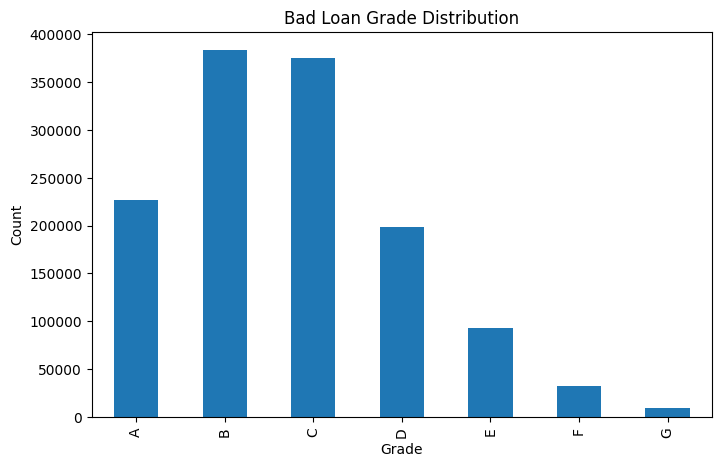

In [26]:
# 불량 대출 등급 분포
plt.figure(figsize=(8,5))

bad_loan_status_to_grades.sort_index().plot(
    kind='bar'
)

plt.title('Bad Loan Grade Distribution')
plt.xlabel('Grade')
plt.ylabel('Count')

plt.show()
plt.close()

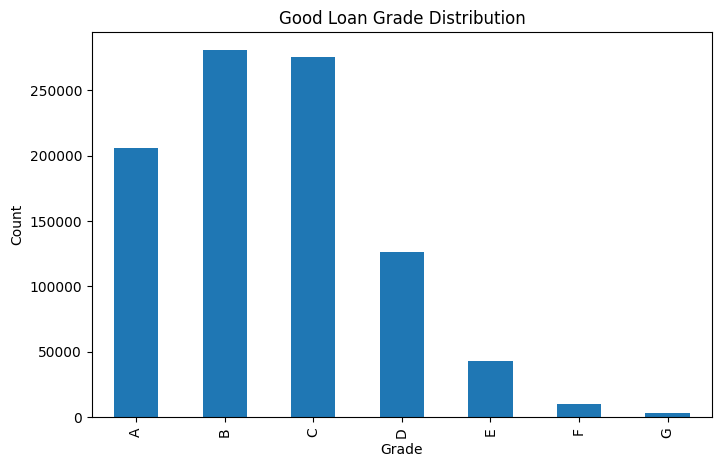

In [27]:
# 우량 대출 등급 분포
plt.figure(figsize=(8,5))

good_loan_status_to_grades.sort_index().plot(
    kind='bar'
)

plt.title('Good Loan Grade Distribution')
plt.xlabel('Grade')
plt.ylabel('Count')

plt.show()
plt.close()

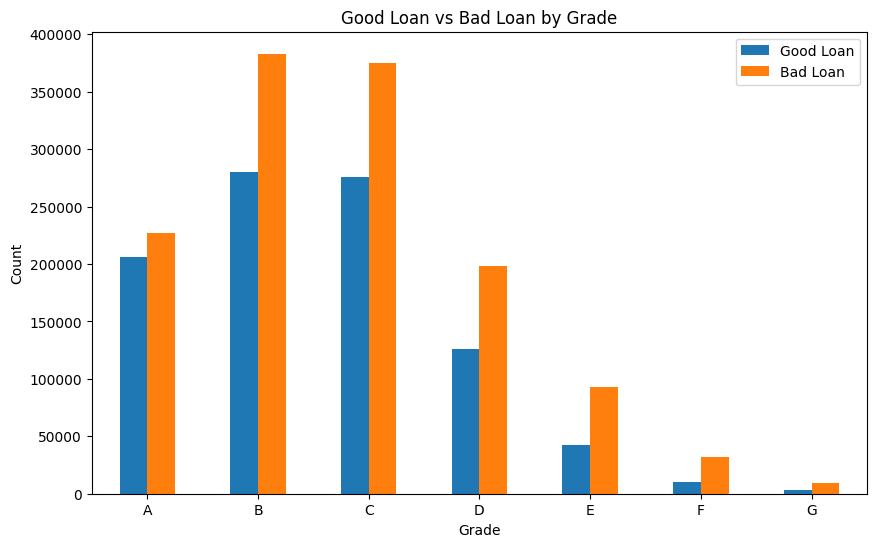

In [28]:
# 우량/불량 등급 분포를 Series로 정렬
good_grade_counts = good_loan_status_to_grades.sort_index()
bad_grade_counts = bad_loan_status_to_grades.sort_index()

# 두 Series를 하나의 DataFrame으로 결합
compare_df = pd.concat(
    [good_grade_counts, bad_grade_counts],
    axis=1
)

# 컬럼명 지정
compare_df.columns = ['Good Loan', 'Bad Loan']

# 결측값이 있으면 0으로 대체
compare_df = compare_df.fillna(0)

# 시각화
compare_df.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Good Loan vs Bad Loan by Grade')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# 대출 총액과 대출 이자율 간의 상관관계 파악

In [66]:
df2.head()

,loan_amnt,loan_status,grade,int_rate,term,bad_loan_status
0,5000.0,Fully Paid,B,10.65,36 months,False
1,2500.0,Charged Off,C,15.27,60 months,True
2,2400.0,Fully Paid,C,15.96,36 months,False
3,10000.0,Fully Paid,C,13.49,36 months,False
4,3000.0,Current,B,12.69,60 months,False


In [68]:
df2['loan_amnt'].corr(df2['int_rate'])
# 0.145.. 로 상관관계가 크지 않다

'''  대출금액(loan_amnt)이 증가할수록 이자율(int_rate)도 약간 증가하는 경향은 있지만, 매우 약한 수준
+1 : 완벽한 양의 상관관계
0 : 상관관계 없음
-1 : 완벽한 음의 상관관계

| 상관계수(|r|) | 해석 |
|------------|------|
| 0.0 ~ 0.1 | 거의 없음 |
| 0.1 ~ 0.3 | 약한 상관관계 |
| 0.3 ~ 0.5 | 보통 상관관계 |
| 0.5 ~ 0.7 | 강한 상관관계 |
| 0.7 ~ 1.0 | 매우 강한 상관관계 |
'''

0.14502309929883933

In [30]:
grade_status = pd.crosstab(
    df2['grade'],
    df2['bad_loan_status'],
    normalize='index'
)

grade_status

bad_loan_status,False,True
grade,,
A,0.475349,0.524651
B,0.422695,0.577305
C,0.423730,0.576270
D,0.388828,0.611172
E,0.315381,0.684619
F,0.236316,0.763684
G,0.247452,0.752548


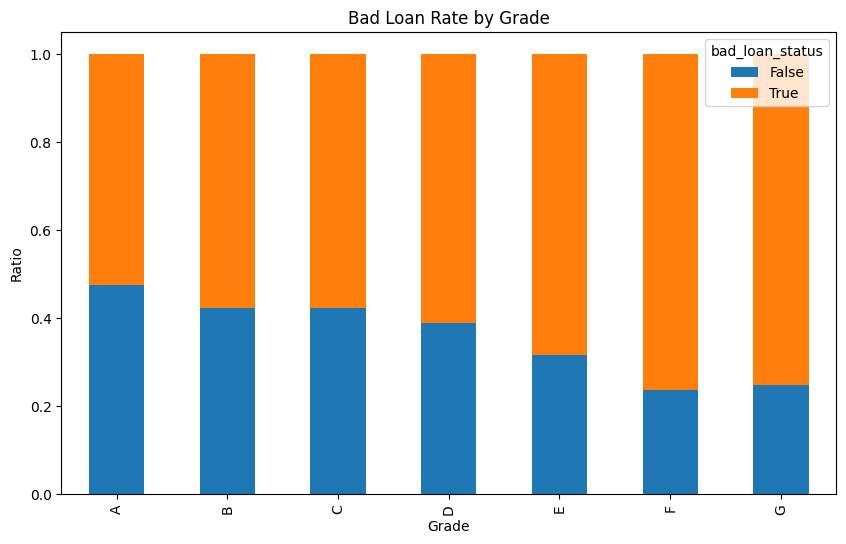

In [31]:
grade_status.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Bad Loan Rate by Grade')
plt.xlabel('Grade')
plt.ylabel('Ratio')
plt.show()

# 해석
Lending Club 대출은 B등급과 C등급 고객에게 가장 많이 실행되었다. 또한 A~G 모든 등급에서 불량 대출 건수가 우량 대출 건수보다 높게 나타났다. 다만 이는 절대 건수 기준의 결과이므로 등급별 위험도를 정확히 판단하기 위해서는 건수보다 부실률(Default Rate) 분석이 필요하다

# 파일쓰기

In [70]:
bad_loan_status_to_grades

C    19054
D    15859
B    13456
E     9745
F     4383
A     3663
G     1269
Name: grade, dtype: int64

In [78]:
bad_loan_status_to_grades.sort_index().to_csv('bad_loan_status.csv', sep = ',')

In [79]:
fileread = pd.read_csv('bad_loan_status.csv', sep=',')
fileread

,A,3663
0,B,13456
1,C,19054
2,D,15859
3,E,9745
4,F,4383
5,G,1269


**fff**

In [31]:
print(type(pd))

print(type(good_loan_status_to_grades))
print(type(bad_loan_status_to_grades))

print(good_loan_status_to_grades.head())
print(bad_loan_status_to_grades.head())

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
grade
B    280482
C    275447
A    205839
D    126145
E     42778
Name: count, dtype: int64
grade
B    383075
C    374606
A    227188
D    198279
E     92861
Name: count, dtype: int64
